In [152]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from pyomo.environ import *
from optimization_utils import *
from param_loader import METANET_Params
from simulation_utils import *
from mpc_utils import *
from eval_metrics import *
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# rho_hat = df["Density"]
# q_hat = df["Flow"]
# print(max(q_hat))
# C_i = np.mean(sorted(q_hat)[-5:])
# print("C_i", C_i)
# K = len(rho_hat)

q_hat = np.load("data/flow_10sec_400m_1hr.npy")
print(np.max(q_hat))
rho_hat = np.load("data/density_10sec_400m_1hr.npy")
v_hat = q_hat / rho_hat
print(rho_hat.shape)
flattened_q_hat = q_hat.flatten()
print(max(flattened_q_hat))
flattened_rho_hat = rho_hat.flatten()
C_i = np.mean(np.sort(flattened_q_hat)[-5:])
print("C_i", C_i)
K = len(flattened_rho_hat)
print("K", K)

rho_hat = np.where(rho_hat == 0.0, 1e-3, rho_hat)
q_hat = np.where(q_hat == 0.0, 1e-3, q_hat)
print(np.min(q_hat/rho_hat))


6773.200199999966
(360, 16)
6773.200199999966
C_i 6718.716719999977
K 5760
3.114799360447148


In [3]:
print(rho_hat.shape)
print(q_hat.shape)

(360, 16)
(360, 16)


In [119]:
random.seed(1)
np.random.seed(1)

np.set_printoptions(suppress=True)

T = 10 / 3600
l = 0.4
num_calibrated_segments = rho_hat.shape[1] - 2
include_ramping = True
varylanes = False
control_h = 360

In [120]:
calibrate_params_mpc(
    rho_hat,
    q_hat,
    T,
    l,
    control_h,
    pred_h = None,
    num_calibrated_segments=num_calibrated_segments,
    include_ramping=include_ramping,
    varylanes=varylanes,
    smoothing=True,
    constraint_tol=1e-12,
    verbose=True,
    results_root_dir="mpc_calibration_results"
)

Running sim for time steps 360, segments 14
(361, 14)
Density mismatch at step 0 of 0.0
Results saved to mpc_calibration_results/1_of_1/
Calibration over 360 time steps with control horizon 360 completed.


In [121]:
num_lanes_array = np.array([4 for i in range(num_calibrated_segments)])

scaled_rho_hat = rho_hat[:, 1:-1] / np.array(num_lanes_array)
downstream_density = smooth_inflow(rho_hat[:, -1] / num_lanes_array[-1])
data_inflow = smooth_inflow(q_hat[:, 0])
init_traffic_state = (scaled_rho_hat[0, :], v_hat[0, 1:-1], data_inflow[0], 0)

v_pred , v_sim = simulate_multiple_params(
    init_traffic_state,
    downstream_density,
    data_inflow,
    T,
    l,
    control_h,
    root_results_dir="mpc_calibration_results")

Running sim for time steps 360, segments 14


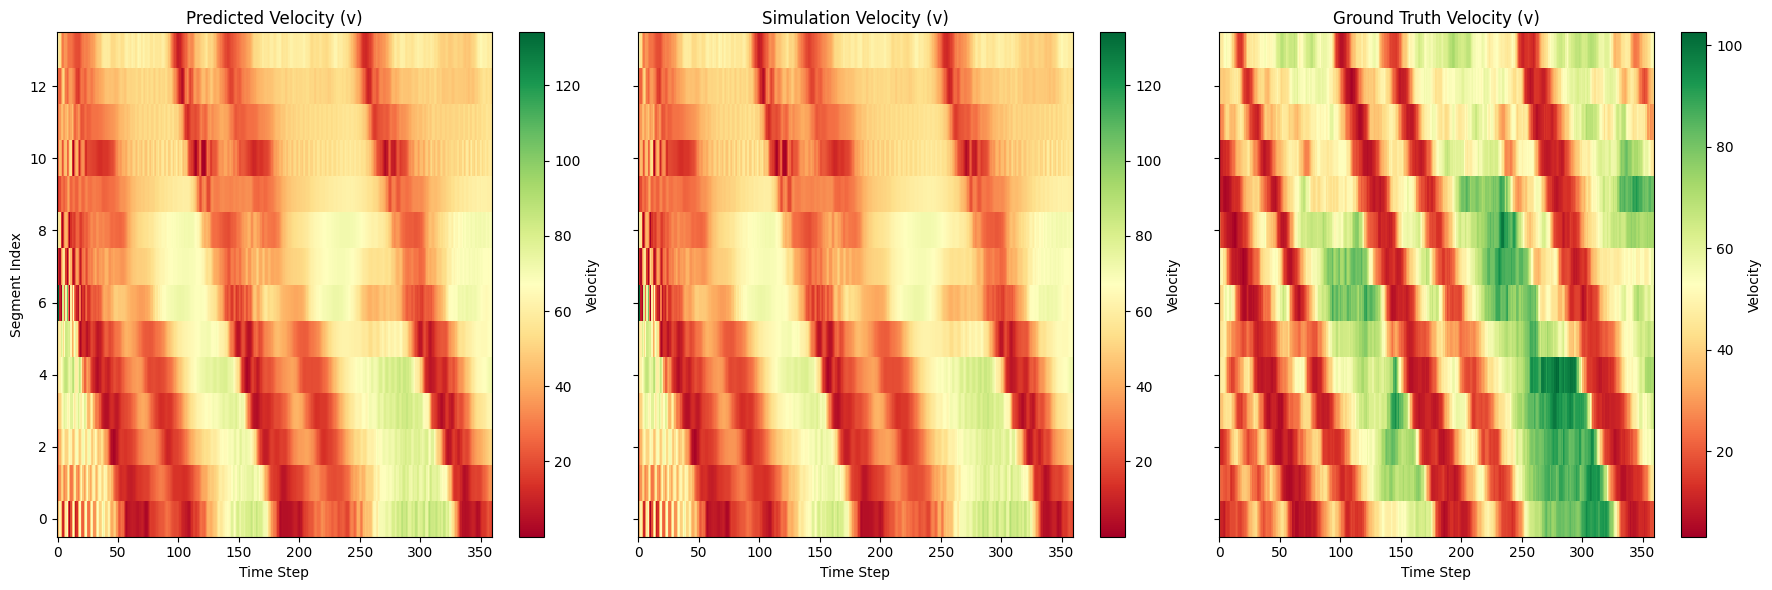

In [122]:
v_plot_true = v_hat[:, 1:-1]


fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# --- Prediction ---
im0 = axes[0].imshow(
    v_pred.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Segment Index")
axes[0].set_title("Predicted Velocity (v)")
fig.colorbar(im0, ax=axes[0], label="Velocity")

# --- Simulation ---
im1 = axes[1].imshow(
    v_sim.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[1].set_xlabel("Time Step")
axes[1].set_title("Simulation Velocity (v)")
fig.colorbar(im1, ax=axes[1], label="Velocity")


# --- Ground Truth ---
im2 = axes[2].imshow(
    v_plot_true.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[2].set_xlabel("Time Step")
axes[2].set_title("Ground Truth Velocity (v)")
fig.colorbar(im2, ax=axes[2], label="Velocity")

plt.tight_layout()
plt.show()



In [147]:
print(f"Param error: {mape(v_hat[:, 1:-1], v_sim[:, :])}")


Param error: 37.663325511860144


In [163]:
test_dir = "mpc_calibration_results/1_of_1"

params =  METANET_Params(path=test_dir, num_segments=num_calibrated_segments).get_params()
num_lanes_array = np.load(os.path.join(test_dir, "num_lanes.npy"))

print_err = True

for epsilon in [1e-13, 1e-7, 1e-4, 0.01, 0.1, 1]:
    true_err_stat, robustness = eval_robustness_static(v_hat[:, 1:-1], params, data_inflow, downstream_density, init_traffic_state, 
                                        lanes=num_lanes_array, T=T, l=l, percent_noise=epsilon)
    

    true_err_dyn, robustness_dynamic = eval_robustness_dynamic(v_hat[:, 1:-1], 10, "mpc_calibration_results", data_inflow, downstream_density, 
                                                init_traffic_state, T=T, l=l, percent_noise=epsilon)
    
    if print_err:
        print(f"True param error (static): {true_err_stat}")
        print(f"True param error (dynamic): {true_err_dyn}")
        print_err = False

    print(f"------ With {epsilon}% noise level on inflows ------")  
    
    print(f"Robustness error for STATIC: {robustness}")
    print(f"Robustness error for DYNAMIC: {robustness_dynamic}")

True param error (static): 37.663325511860144
True param error (dynamic): 7.334007300704212
------ With 1e-13% noise level on inflows ------
Robustness error for STATIC: 37.668181576023215
Robustness error for DYNAMIC: 270349.2634918642
------ With 1e-07% noise level on inflows ------
Robustness error for STATIC: 62.086490822174575
Robustness error for DYNAMIC: 4813288.97455595
------ With 0.0001% noise level on inflows ------
Robustness error for STATIC: 65.19830059977295
Robustness error for DYNAMIC: 235751.9198988229
------ With 0.01% noise level on inflows ------
Robustness error for STATIC: 76.77061863277659
Robustness error for DYNAMIC: 1251913.0754332393
------ With 0.1% noise level on inflows ------
Robustness error for STATIC: 78.56768130343981
Robustness error for DYNAMIC: 1246626.184371781
------ With 1% noise level on inflows ------
Robustness error for STATIC: 84.8501620200579
Robustness error for DYNAMIC: 2380353.851850131


<function matplotlib.pyplot.show(close=None, block=None)>

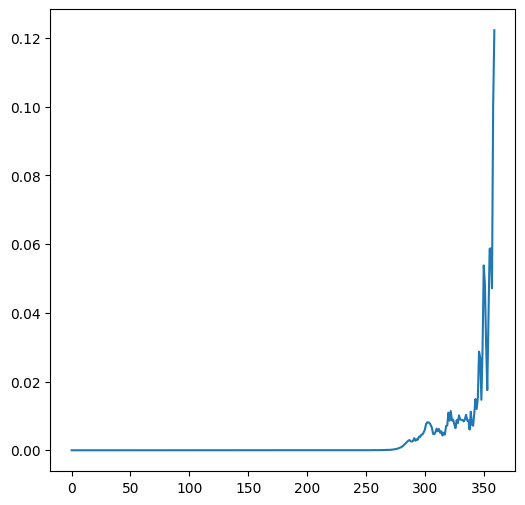

In [124]:
# Plot error between pred and sim 
err = np.abs(v_pred - v_sim)
fig, ax = plt.subplots(figsize=(6, 6))
plt.plot(err.mean(axis=1))
plt.show

Calibration-Simulation Error: 5.168463458839359e-07
Simulation MAPE wrt GT: 26.54398807730952


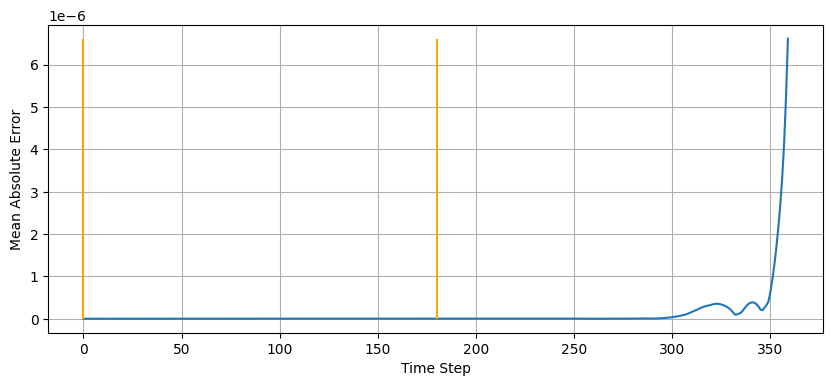

In [59]:
# Plot error between v_pred and v_sim for both horizons separately
print("Calibration-Simulation Error:", mape(v_pred, v_sim))
print("Simulation MAPE wrt GT:", mape(v_plot_true, v_sim))

sim_cal_error = np.abs(v_pred - v_sim).mean(axis=1)
plt.figure(figsize=(10, 4))
plt.plot(sim_cal_error)
plt.xlabel("Time Step")
plt.ylabel("Mean Absolute Error")

# plot vertical line for each horizon
for i in range(0, 360, control_h):
    plt.vlines(i, ymin=0, ymax=max(sim_cal_error), colors="orange")
plt.grid()
plt.show()

Text(0, 0.5, 'Mean Absolute Error')

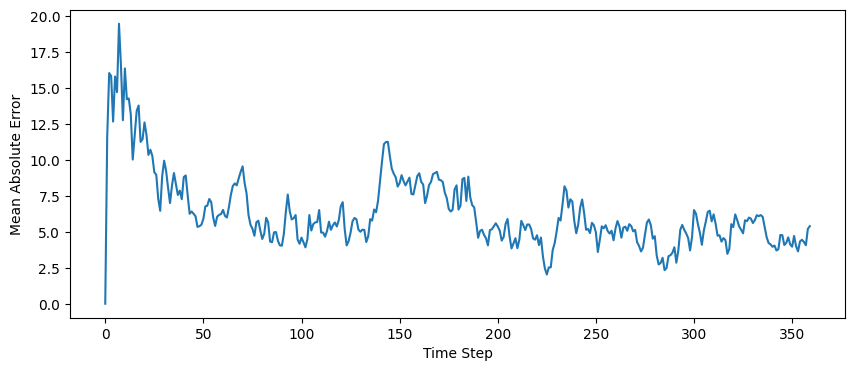

In [57]:
# Plot sim vs gt error
sim_gt_error = np.abs(v_plot_true - v_sim).mean(axis=1)
plt.figure(figsize=(10, 4))
plt.plot(sim_gt_error)
plt.xlabel("Time Step")
plt.ylabel("Mean Absolute Error")

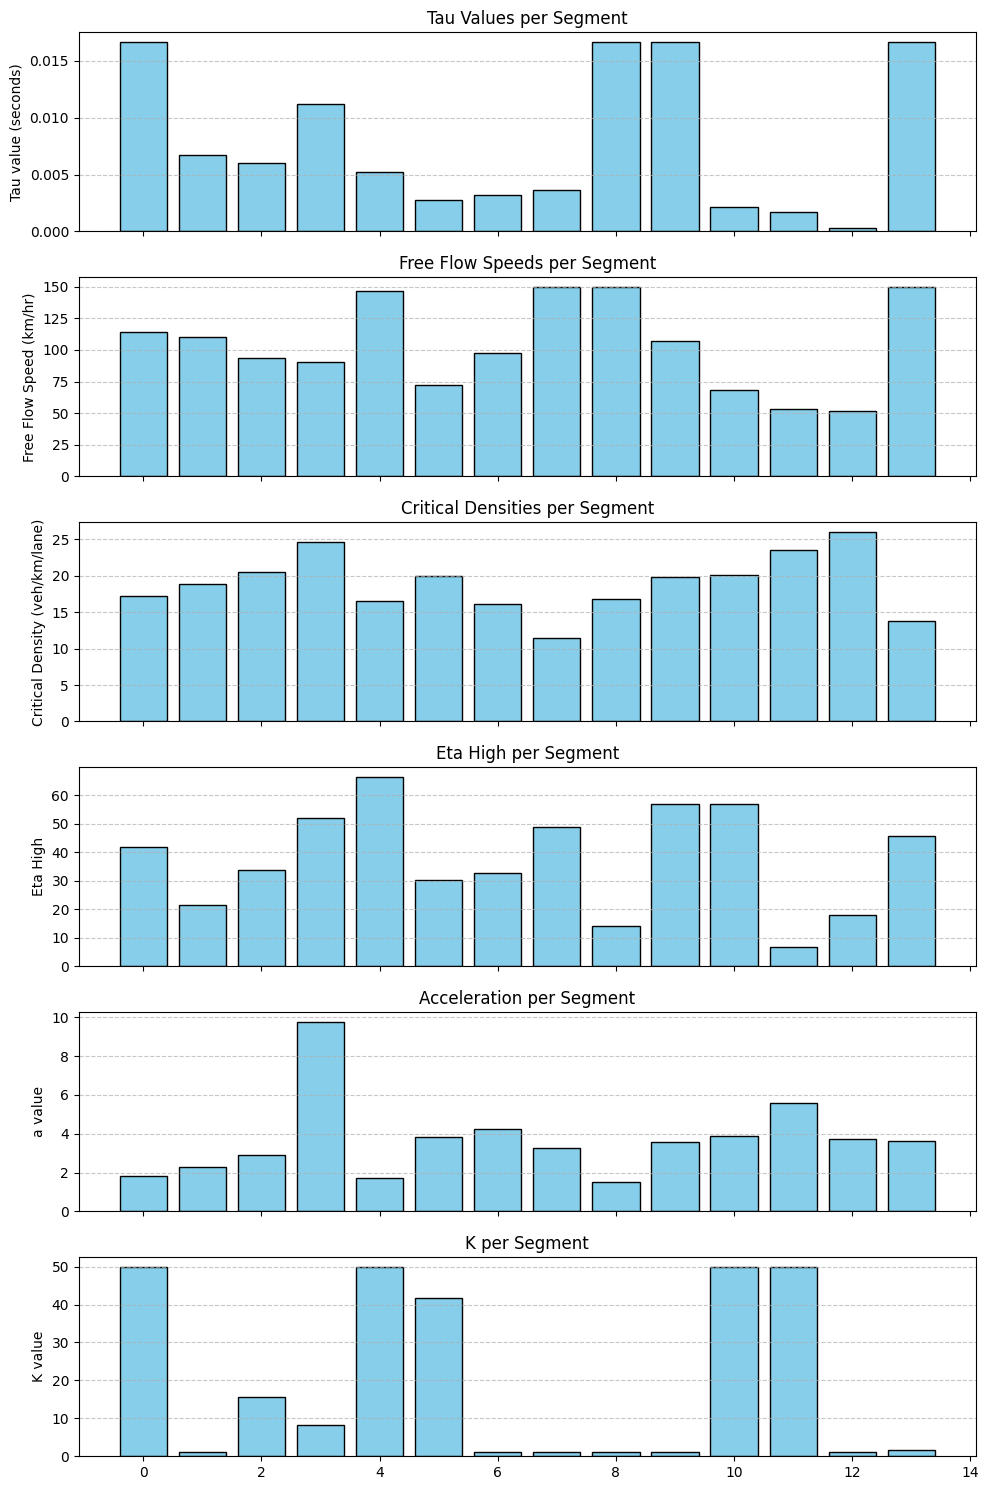

In [95]:
# Plot parameters in bar chart, show default value
test_params = METANET_Params(path='calibration_results/test', num_segments=num_calibrated_segments).get_params()
fig, axes = plt.subplots(6, 1, figsize=(10, 15), sharex=True)
axes[0].bar(
    np.arange(len(tau_array)), test_params["tau"], color="skyblue", edgecolor="black"
)

axes[0].set_ylabel("Tau value (seconds)")
axes[0].set_title("Tau Values per Segment")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

axes[1].bar(
    np.arange(len(v_free_array)), test_params["v_free"], color="skyblue", edgecolor="black"
)
axes[1].set_ylabel("Free Flow Speed (km/hr)")
axes[1].set_title("Free Flow Speeds per Segment")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

axes[2].bar(
    np.arange(len(rho_crit_array)), test_params["p_crit"], color="skyblue", edgecolor="black"
)
axes[2].set_ylabel("Critical Density (veh/km/lane)")
axes[2].set_title("Critical Densities per Segment")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

axes[3].bar(
    np.arange(len(eta_high_array)), test_params["eta_high"], color="skyblue", edgecolor="black"
)
axes[3].set_ylabel("Eta High")
axes[3].set_title("Eta High per Segment")
axes[3].grid(axis="y", linestyle="--", alpha=0.7)

axes[4].bar(
    np.arange(len(a_array)), test_params["a"], color="skyblue", edgecolor="black"
)
axes[4].set_ylabel("a value")
axes[4].set_title("Acceleration per Segment")
axes[4].grid(axis="y", linestyle="--", alpha=0.7)

axes[5].bar(
    np.arange(len(K_array)), test_params["K"], color="skyblue", edgecolor="black"
)
axes[5].set_ylabel("K value")
axes[5].set_title("K per Segment")
axes[5].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

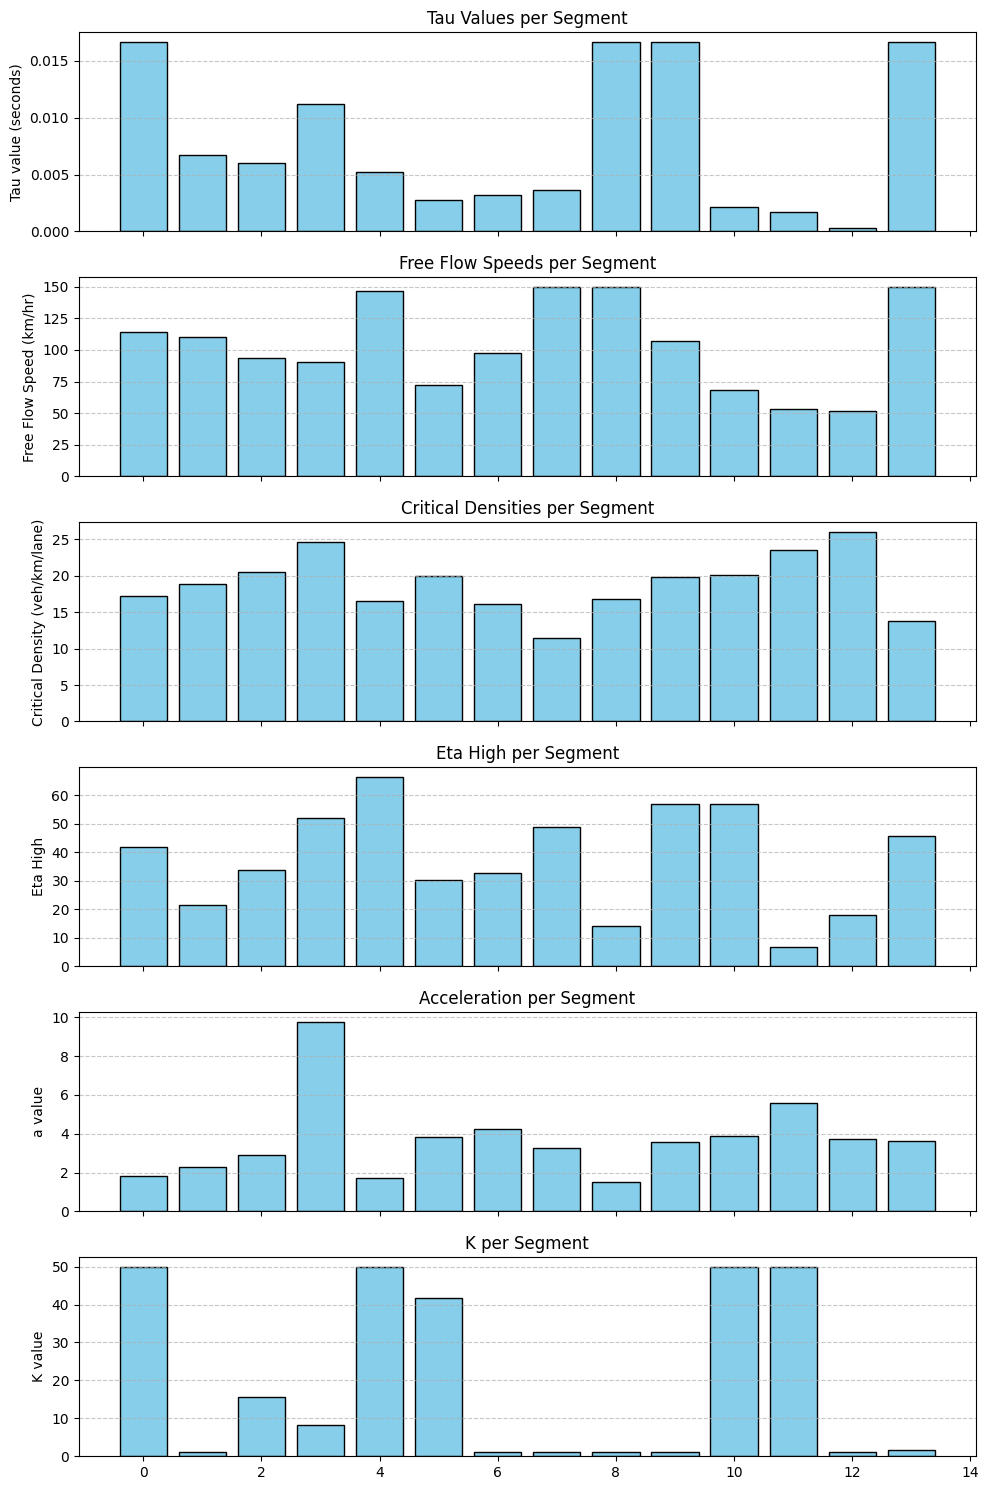

In [96]:
# Plot parameters in bar chart, show default value
roll1_params = METANET_Params(path='calibration_results/rolling1', num_segments=num_calibrated_segments).get_params()
fig, axes = plt.subplots(6, 1, figsize=(10, 15), sharex=True)
axes[0].bar(
    np.arange(len(tau_array)), roll1_params["tau"], color="skyblue", edgecolor="black"
)

axes[0].set_ylabel("Tau value (seconds)")
axes[0].set_title("Tau Values per Segment")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

axes[1].bar(
    np.arange(len(v_free_array)), roll1_params["v_free"], color="skyblue", edgecolor="black"
)
axes[1].set_ylabel("Free Flow Speed (km/hr)")
axes[1].set_title("Free Flow Speeds per Segment")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

axes[2].bar(
    np.arange(len(rho_crit_array)), roll1_params["p_crit"], color="skyblue", edgecolor="black"
)
axes[2].set_ylabel("Critical Density (veh/km/lane)")
axes[2].set_title("Critical Densities per Segment")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

axes[3].bar(
    np.arange(len(eta_high_array)), roll1_params["eta_high"], color="skyblue", edgecolor="black"
)
axes[3].set_ylabel("Eta High")
axes[3].set_title("Eta High per Segment")
axes[3].grid(axis="y", linestyle="--", alpha=0.7)

axes[4].bar(
    np.arange(len(a_array)), roll1_params["a"], color="skyblue", edgecolor="black"
)
axes[4].set_ylabel("a value")
axes[4].set_title("Acceleration per Segment")
axes[4].grid(axis="y", linestyle="--", alpha=0.7)

axes[5].bar(
    np.arange(len(K_array)), roll1_params["K"], color="skyblue", edgecolor="black"
)
axes[5].set_ylabel("K value")
axes[5].set_title("K per Segment")
axes[5].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

Text(0.5, 1.0, 'Smoothed Inflow Comparison')

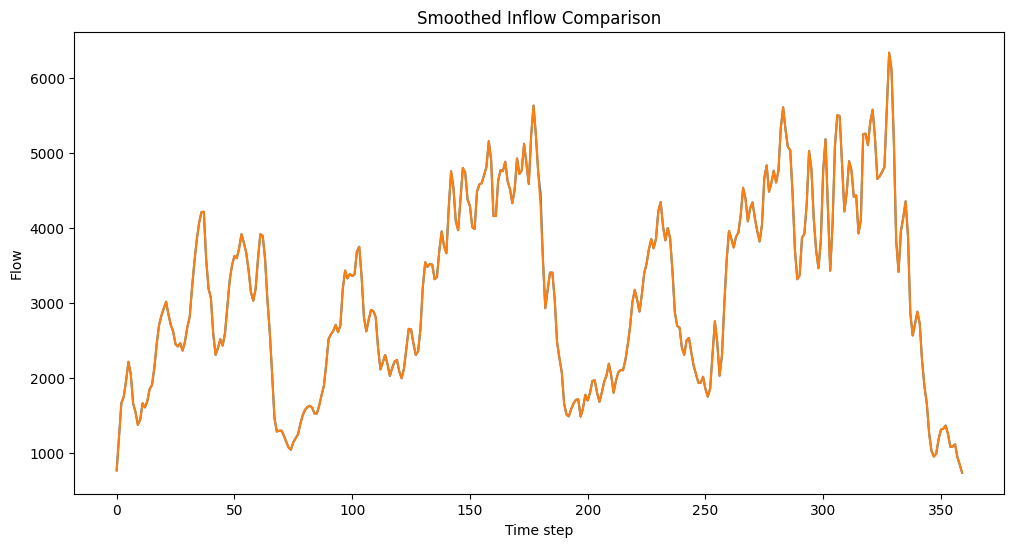

In [20]:
# Plot smoothed inflow for the entire 360 versus smoothing first 180 and second 180 separately
plt.figure(figsize=(12, 6))
plt.plot(smooth_inflow(q_hat[:, 0]), label='Smoothed Inflow (360)')
plt.plot(np.hstack((smooth_inflow(q_hat[0:180, 0]), smooth_inflow(q_hat[180:, 0]))), label='Smoothed Inflow (180)')
plt.xlabel('Time step')
plt.ylabel('Flow')
plt.title('Smoothed Inflow Comparison')